## Exploratory Data Analysis (EDA)
Analyze the cleaned dataset to understand customer behavior and sales trends.

Key Questions:
- Which countries generate the most revenue?
- What are the monthly sales trends?
- Which products are most popular?
- Who are the top customers?

## Load Cleaned Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('~/Customer-Segmentation-and-Churn-Analysis/data/cleaned_data.csv')

## Top Countries by Revenue

In [3]:
# Create TotalPrice column (Quantity × UnitPrice)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [4]:
# Top 10 countries by total revenue
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

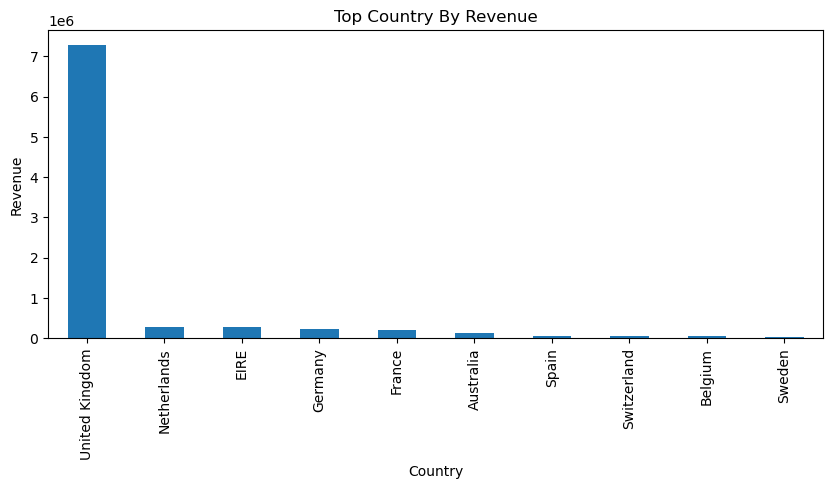

In [5]:
# Plot
plt.figure(figsize=(10,4))
country_sales.head(10).plot(kind="bar")

plt.title('Top Country By Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.show()

The top 10 countries contribute the majority of total revenue, indicating that sales are concentrated in a few key markets.

## Monthly Revenue Trend

In [6]:
# Calculate total revenue for each month
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')["TotalPrice"].sum()
monthly_sales

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalPrice, dtype: float64

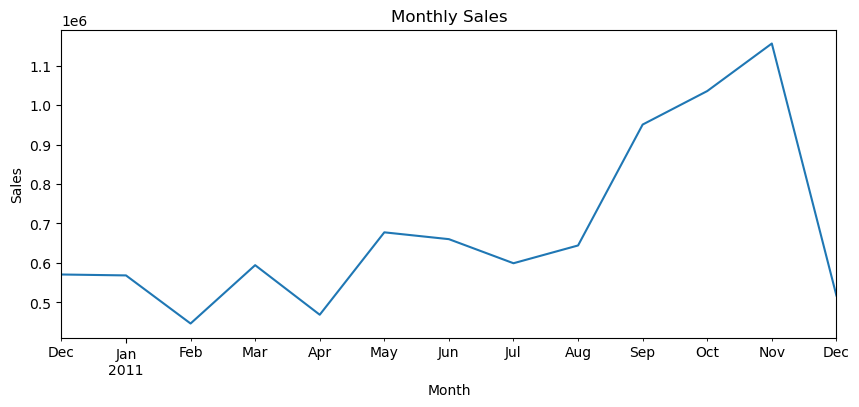

In [7]:
# Plot
plt.figure(figsize=(10,4))
monthly_sales.plot()

plt.title('Monthly Sales')
plt.ylabel('Sales')
plt.xlabel('Month')

plt.show()

Revenue shows an overall trend with periodic peaks, suggesting seasonal variations in sales and potential high-demand periods.

## Top-Selling Products

In [8]:
# Top 10 products by total quantity sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

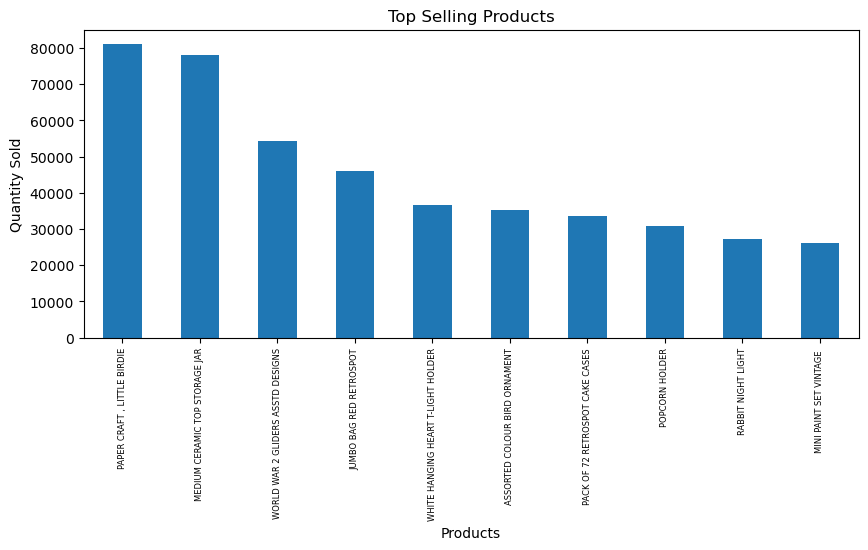

In [9]:
# Plot
plt.figure(figsize=(10,4))
top_products.head(10).plot(kind='bar')

plt.title("Top Selling Products")
plt.xlabel('Products')
plt.ylabel('Quantity Sold')
plt.xticks(fontsize=6, rotation=90)

plt.show()

A small number of products account for a large portion of total sales, indicating high demand concentration on specific items.

## Top Customers by Revenue

In [10]:
# Top 10 customers by total revenue
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)
top_customers.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

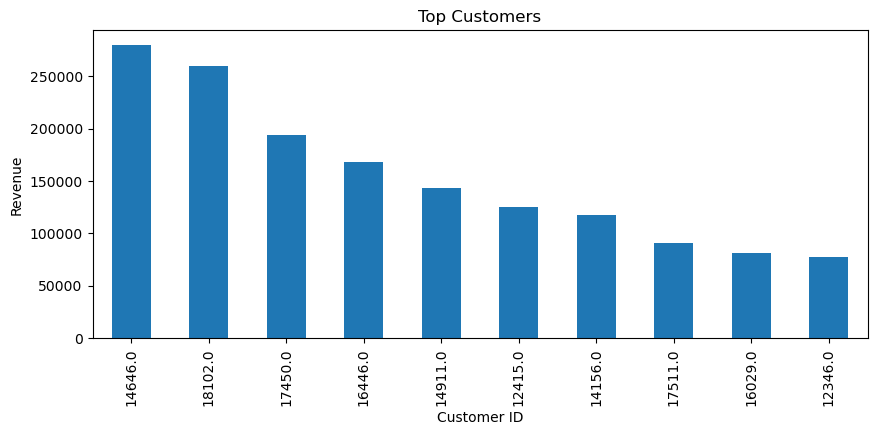

In [11]:
# Plot
plt.figure(figsize=(10,4))
top_customers.head(10).plot(kind='bar')

plt.title("Top Customers")
plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.show()

A small group of customers contributes significantly to total revenue, highlighting the importance of high-value customers.

## Customer Purchase Frequency Distribution

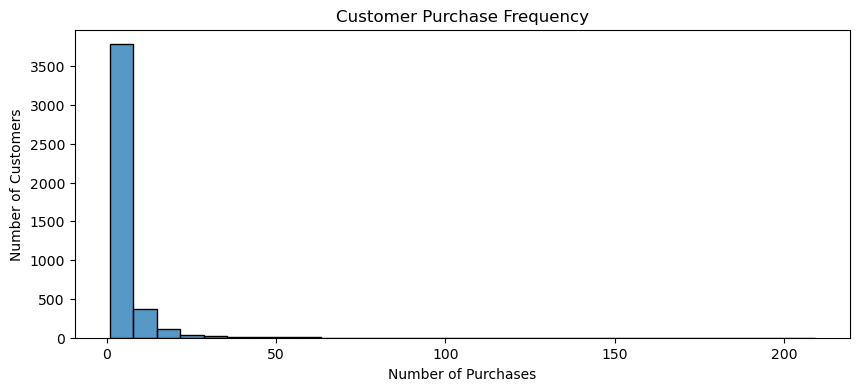

In [12]:
# Calculate purchase frequency for each customer
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

# Plot distribution of purchase frequency
plt.figure(figsize=(10,4))
sns.histplot(purchase_frequency, bins=30)
plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.show()

Most customers make a limited number of purchases, while a small segment purchases frequently, indicating an uneven distribution of customer engagement.

## Key Insights from EDA

- Most revenue comes from a few countries.
- Certain products are significantly more popular than others.
- A small number of customers generate a large portion of total revenue.
- Most customers make only a few purchases.